<a href="https://colab.research.google.com/github/Harini-Sri-Vedha-Alvar/Fake-Job-Post-Prediction-ML-Project-/blob/main/FAKE_JOB_POST_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load the fake job posting dataset and prepare the basic Python libraries needed for the project

from google.colab import drive
import pandas as pd
import numpy as np
import re

drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/fake_job_postings.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Dataset shape: (17880, 18)


In [ ]:
# Understand the structure, columns, data types, and sample records in the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nFirst 5 records:")
display(df.head())

Number of rows: 17880
Number of columns: 18

Column names:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Data types:


,Data Type
job_id,int64
title,object
location,object
department,object
salary_range,object
company_profile,object
description,object
requirements,object
benefits,object
telecommuting,int64



First 5 records:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
# Identify missing values in every column and calculate their percentage

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_count,
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


In [ ]:
# Check whether the dataset contains duplicate job posting records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count == 0:
    print("No duplicate rows found.")
else:
    print("Duplicate rows are present and will need to be handled.")

Number of duplicate rows: 0
No duplicate rows found.


,Job Type,Count,Percentage
0,Legitimate,17014,95.16
1,Fraudulent,866,4.84


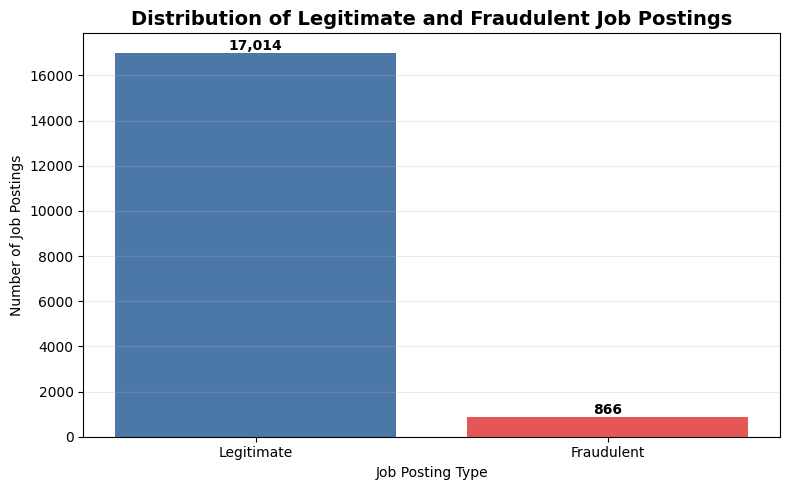

In [ ]:
# Analyze the distribution of legitimate and fraudulent job postings

class_counts = df["fraudulent"].value_counts().sort_index()
class_percent = df["fraudulent"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Job Type": ["Legitimate", "Fraudulent"],
    "Count": class_counts.values,
    "Percentage": class_percent.round(2).values
})

display(class_summary)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_summary["Job Type"],
    class_summary["Count"],
    color=["#4C78A8", "#E45756"]
)

plt.title("Distribution of Legitimate and Fraudulent Job Postings", fontsize=14, fontweight="bold")
plt.xlabel("Job Posting Type")
plt.ylabel("Number of Job Postings")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


Fraudulent-job percentage by has_company_logo:


,Fraudulent Percentage
has_company_logo,
0,15.93
1,1.99


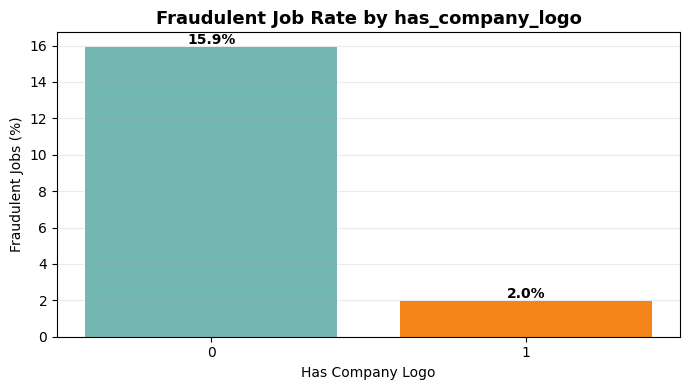


Fraudulent-job percentage by has_questions:


,Fraudulent Percentage
has_questions,
0,6.78
1,2.84


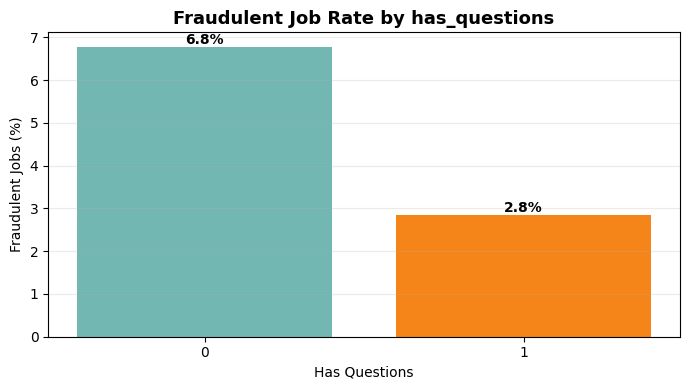


Fraudulent-job percentage by telecommuting:


,Fraudulent Percentage
telecommuting,
1,8.34
0,4.69


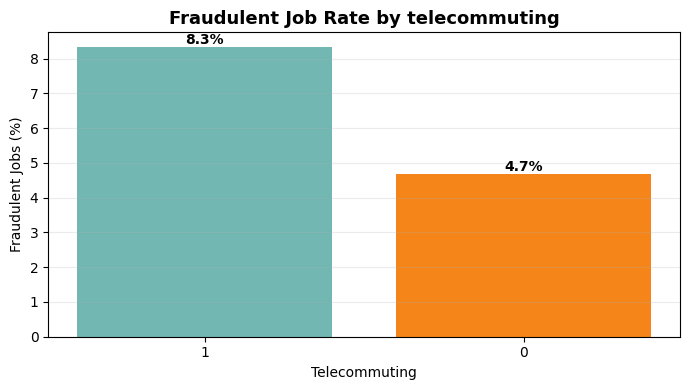

In [ ]:
# Compare fraudulent-job rates across important categorical job-posting characteristics

categorical_features = [
    "has_company_logo",
    "has_questions",
    "telecommuting"
]

for column in categorical_features:
    rate = df.groupby(column)["fraudulent"].mean().mul(100).round(2).sort_values(ascending=False)

    print(f"\nFraudulent-job percentage by {column}:")
    display(rate.to_frame("Fraudulent Percentage"))

    plt.figure(figsize=(7, 4))

    bars = plt.bar(
        rate.index.astype(str),
        rate.values,
        color=["#72B7B2", "#F58518"]
    )

    plt.title(
        f"Fraudulent Job Rate by {column}",
        fontsize=13,
        fontweight="bold"
    )
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Fraudulent Jobs (%)")
    plt.grid(axis="y", alpha=0.25)

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()

,Fraudulent Percentage
employment_type,
Part-time,9.284818
Other,6.607930
Full-time,4.216867
Contract,2.887139
Temporary,0.829876


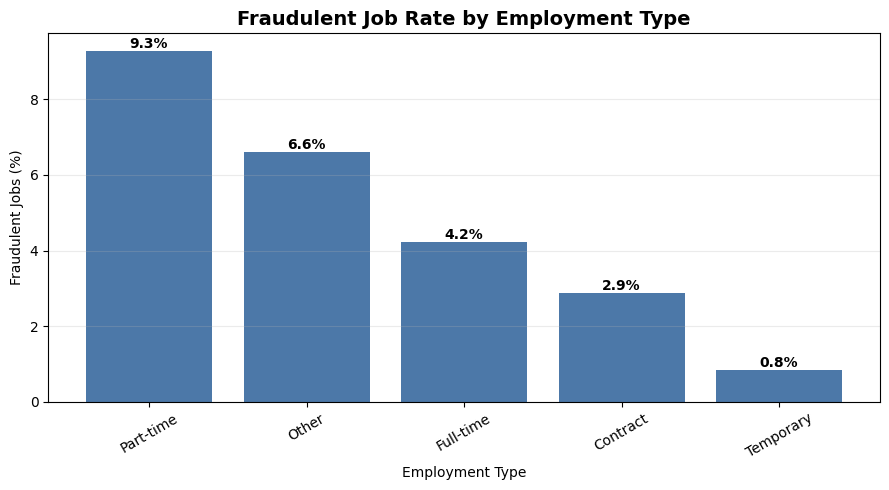

In [ ]:
# Compare fraudulent-job rates across different employment types

employment_rate = (
    df.groupby("employment_type")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(employment_rate.to_frame("Fraudulent Percentage"))

plt.figure(figsize=(9, 5))

bars = plt.bar(
    employment_rate.index.astype(str),
    employment_rate.values,
    color="#4C78A8"
)

plt.title("Fraudulent Job Rate by Employment Type", fontsize=14, fontweight="bold")
plt.xlabel("Employment Type")
plt.ylabel("Fraudulent Jobs (%)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

,Fraudulent Percentage
required_experience,
Executive,7.092199
Entry level,6.637004
Not Applicable,5.376344
Director,4.370180
Mid-Senior level,2.966658
Internship,2.624672
Associate,1.828472


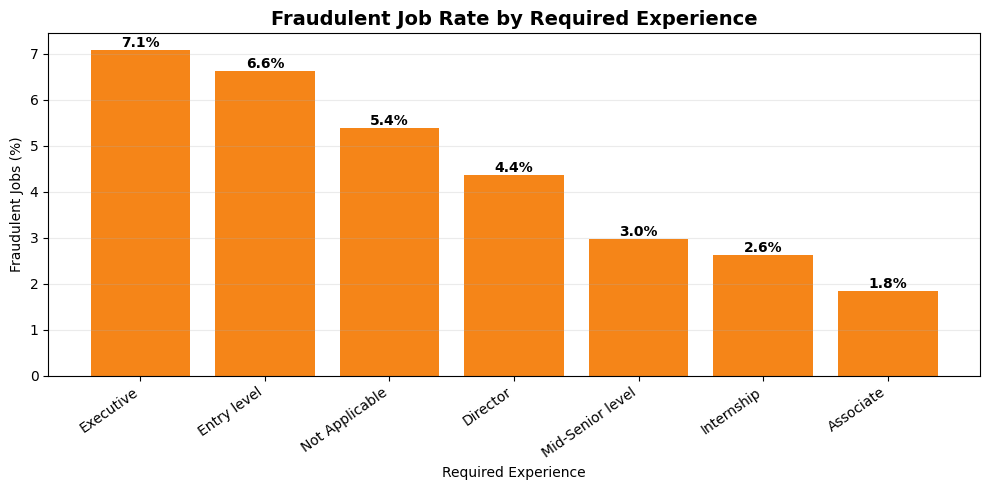

In [ ]:
# Compare fraudulent-job rates across required experience levels

experience_rate = (
    df.groupby("required_experience")["fraudulent"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(experience_rate.to_frame("Fraudulent Percentage"))

plt.figure(figsize=(10, 5))

bars = plt.bar(
    experience_rate.index.astype(str),
    experience_rate.values,
    color="#F58518"
)

plt.title("Fraudulent Job Rate by Required Experience", fontsize=14, fontweight="bold")
plt.xlabel("Required Experience")
plt.ylabel("Fraudulent Jobs (%)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Combine the main text fields into one document for natural language processing

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

df["combined_text"] = (
    df[text_columns]
    .fillna("")
    .agg(" ".join, axis=1)
)

print("Combined text column created successfully.")
print("Average text length:", round(df["combined_text"].str.len().mean(), 1), "characters")

display(
    df[["title", "combined_text", "fraudulent"]].head(3)
)

Combined text column created successfully.
Average text length: 2670.5 characters


,title,combined_text,fraudulent
0,Marketing Intern,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA),Commissioning Machinery Assistant (CMA) Valor ...,0


In [ ]:
# Clean the combined job-posting text for natural language processing

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["combined_text"].apply(clean_text)

print("Text cleaning completed successfully.")

display(
    df[["combined_text", "clean_text", "fraudulent"]].head(3)
)

Text cleaning completed successfully.


,combined_text,clean_text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...,0
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...,0


In [ ]:
# Split the cleaned text and target into training and testing sets before TF-IDF transformation

from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["fraudulent"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))
print("Training fraudulent rate:", round(y_train.mean() * 100, 2), "%")
print("Testing fraudulent rate:", round(y_test.mean() * 100, 2), "%")

Training samples: 14304
Testing samples: 3576
Training fraudulent rate: 4.84 %
Testing fraudulent rate: 4.84 %


In [ ]:
# Convert the training and testing job-posting text into numerical TF-IDF features without data leakage

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF transformation completed.")
print("Training feature matrix:", X_train.shape)
print("Testing feature matrix:", X_test.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

TF-IDF transformation completed.
Training feature matrix: (14304, 10000)
Testing feature matrix: (3576, 10000)
Vocabulary size: 10000


In [ ]:
# Train a class-balanced Logistic Regression model to detect fraudulent job postings

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
# Train a class-balanced Random Forest model as a second machine-learning approach

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# Evaluate both models using multiple classification metrics suited to the imbalanced fraud-detection problem

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, y_true, predictions, probabilities):
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities)
    }

    print(f"\n{name}")
    print("=" * len(name))
    print(classification_report(
        y_true,
        predictions,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    ))

    return results

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_probabilities
)

random_forest_results = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_predictions,
    random_forest_probabilities
)

results_df = pd.DataFrame([
    logistic_results,
    random_forest_results
])

display(results_df.round(4))


Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99      3403
  Fraudulent       0.74      0.92      0.82       173

    accuracy                           0.98      3576
   macro avg       0.87      0.95      0.90      3576
weighted avg       0.98      0.98      0.98      3576


Random Forest
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      3403
  Fraudulent       1.00      0.61      0.76       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9804,0.7395,0.9191,0.8196,0.9890
1,Random Forest,0.9810,1.0000,0.6069,0.7554,0.9878


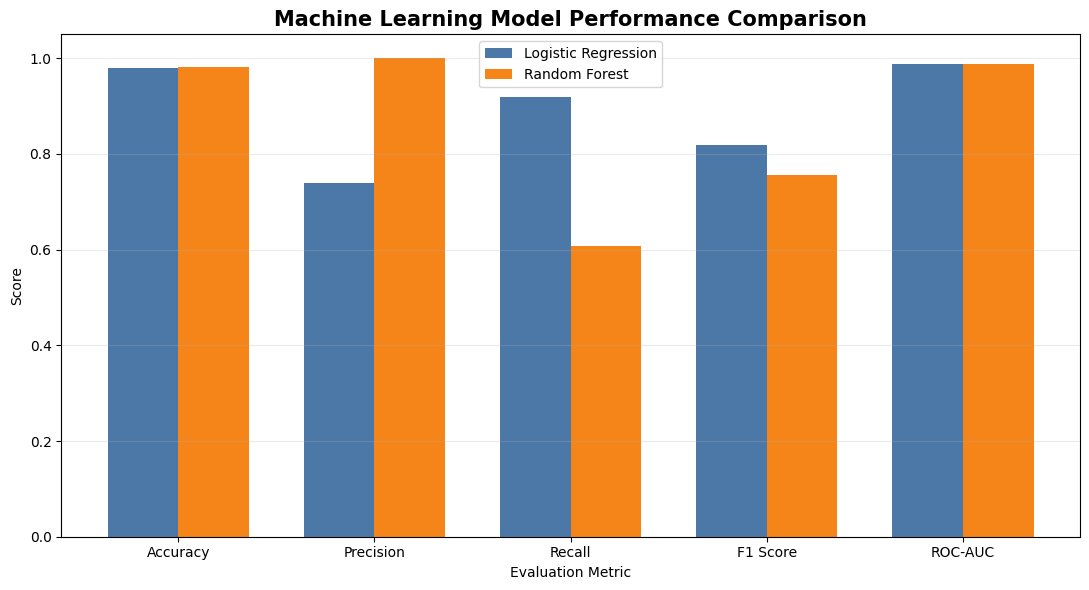

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9804,0.7395,0.9191,0.8196,0.9890
1,Random Forest,0.9810,1.0000,0.6069,0.7554,0.9878


In [ ]:
# Compare Logistic Regression and Random Forest across the main evaluation metrics

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

x = np.arange(len(metrics))
width = 0.36

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    results_df.loc[0, metrics],
    width,
    label="Logistic Regression",
    color="#4C78A8"
)

plt.bar(
    x + width / 2,
    results_df.loc[1, metrics],
    width,
    label="Random Forest",
    color="#F58518"
)

plt.title("Machine Learning Model Performance Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

display(results_df.round(4))

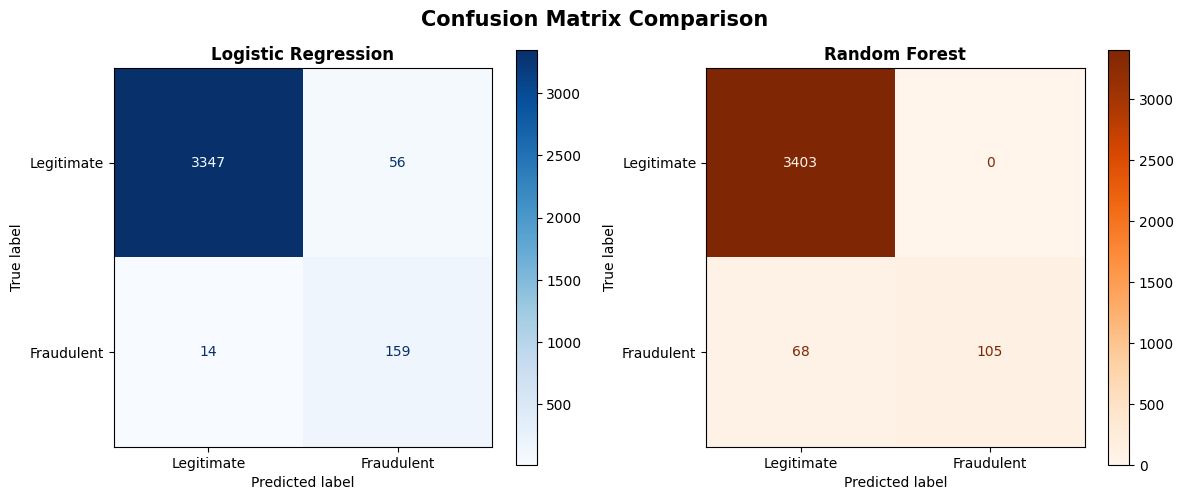

In [ ]:
# Visualize the confusion matrices to understand the types of predictions made by each model

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["Legitimate", "Fraudulent"],
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression", fontweight="bold")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_predictions,
    display_labels=["Legitimate", "Fraudulent"],
    cmap="Oranges",
    ax=axes[1]
)

axes[1].set_title("Random Forest", fontweight="bold")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

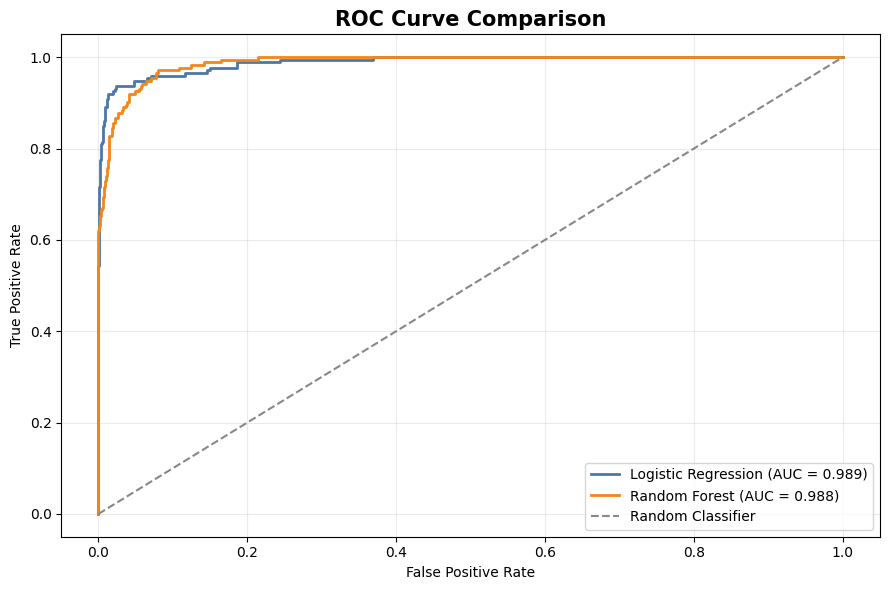

In [ ]:
# Compare the ROC curves of both models to evaluate their ability to separate fraudulent and legitimate jobs

from sklearn.metrics import roc_curve, auc

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    random_forest_probabilities
)

logistic_auc = auc(logistic_fpr, logistic_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(9, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    linewidth=2,
    color="#4C78A8",
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    color="#F58518",
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#888888",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison", fontsize=15, fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Identify the words and phrases that contribute most strongly toward fraudulent and legitimate predictions

feature_names = np.array(tfidf.get_feature_names_out())
logistic_coefficients = logistic_model.coef_[0]

top_fraud_indices = np.argsort(logistic_coefficients)[-20:][::-1]
top_legitimate_indices = np.argsort(logistic_coefficients)[:20]

fraudulent_words = pd.DataFrame({
    "Feature": feature_names[top_fraud_indices],
    "Coefficient": logistic_coefficients[top_fraud_indices]
})

legitimate_words = pd.DataFrame({
    "Feature": feature_names[top_legitimate_indices],
    "Coefficient": logistic_coefficients[top_legitimate_indices]
})

print("Top features associated with fraudulent predictions:")
display(fraudulent_words)

print("Top features associated with legitimate predictions:")
display(legitimate_words)

Top features associated with fraudulent predictions:


,Feature,Coefficient
0,link,4.515071
1,earn,3.812814
2,data entry,3.515100
3,high school,3.206852
4,aptitude staffing,3.176016
5,money,3.091872
6,phone,2.908545
7,aptitude,2.858819
8,clerk,2.784167
9,cash,2.758289


Top features associated with legitimate predictions:


,Feature,Coefficient
0,team,-2.952060
1,english,-2.789026
2,companies,-2.772802
3,recruitment,-2.751104
4,web,-2.599258
5,growing,-2.539525
6,software,-2.527179
7,digital,-2.526144
8,clients,-2.371483
9,fun,-2.355589


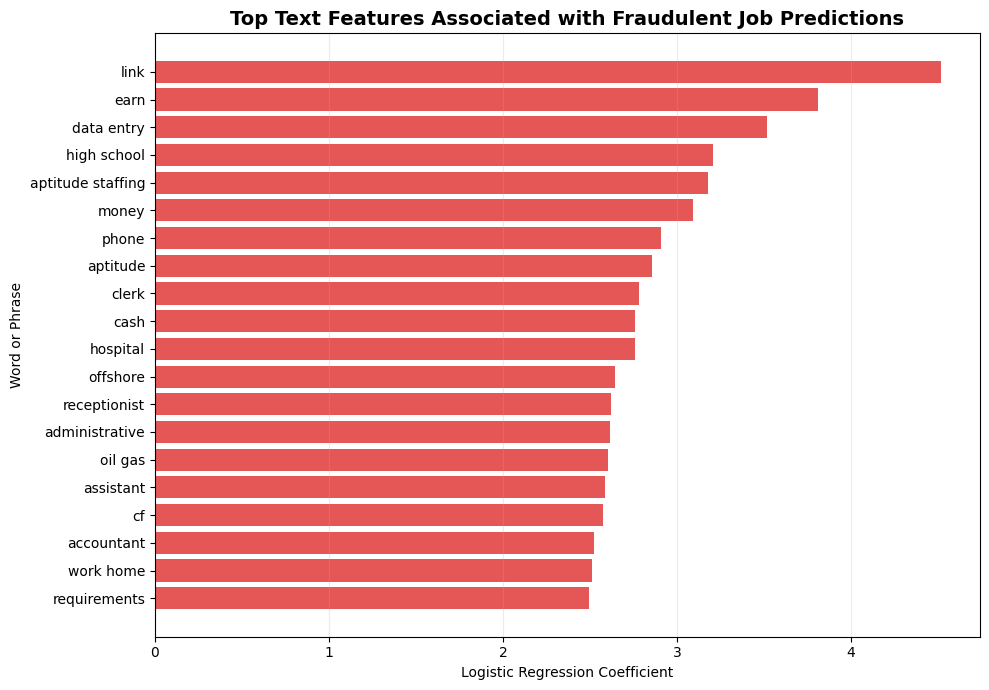

In [ ]:
# Visualize the strongest text features associated with fraudulent and legitimate predictions

fraud_plot = fraudulent_words.sort_values("Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    fraud_plot["Feature"],
    fraud_plot["Coefficient"],
    color="#E45756"
)

plt.title(
    "Top Text Features Associated with Fraudulent Job Predictions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word or Phrase")
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Analyze incorrectly classified job postings to understand common model errors

error_analysis = pd.DataFrame({
    "Text": X_test_text.values,
    "Actual": y_test.values,
    "Predicted": logistic_predictions,
    "Fraud Probability": logistic_probabilities
})

false_positives = error_analysis[
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
].sort_values("Fraud Probability", ascending=False)

false_negatives = error_analysis[
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
].sort_values("Fraud Probability", ascending=False)

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nExamples of false positives:")
display(false_positives.head(5))

print("\nExamples of false negatives:")
display(false_negatives.head(5))

False positives: 56
False negatives: 14

Examples of false positives:


,Text,Actual,Predicted,Fraud Probability
3341,customer service work from home do you have ye...,0,1,0.896670
653,data entry prepares source data for computer e...,0,1,0.830953
1814,supply chain help desk this role will be in bu...,0,1,0.815891
1323,part time administrative data entry i as part ...,0,1,0.804239
3349,receptionist century martinez amp associates h...,0,1,0.789191



Examples of false negatives:


,Text,Actual,Predicted,Fraud Probability
2219,graphite expert remote position position graph...,1,0,0.479929
1800,physician assistant pa dermatology job title p...,1,0,0.463594
904,process validation project manager maynard con...,1,0,0.455784
341,sales manager collaborates with insert title i...,1,0,0.357514
1350,assistant accountant looking for an assistant ...,1,0,0.351228


,Threshold,Precision,Recall,F1 Score
0,0.10,0.153,0.994,0.265
1,0.15,0.220,0.977,0.359
2,0.20,0.292,0.965,0.449
3,0.25,0.362,0.960,0.525
4,0.30,0.430,0.948,0.592
5,0.35,0.502,0.948,0.656
6,0.40,0.562,0.936,0.703
7,0.45,0.661,0.936,0.775
8,0.50,0.740,0.919,0.820
9,0.55,0.807,0.896,0.849


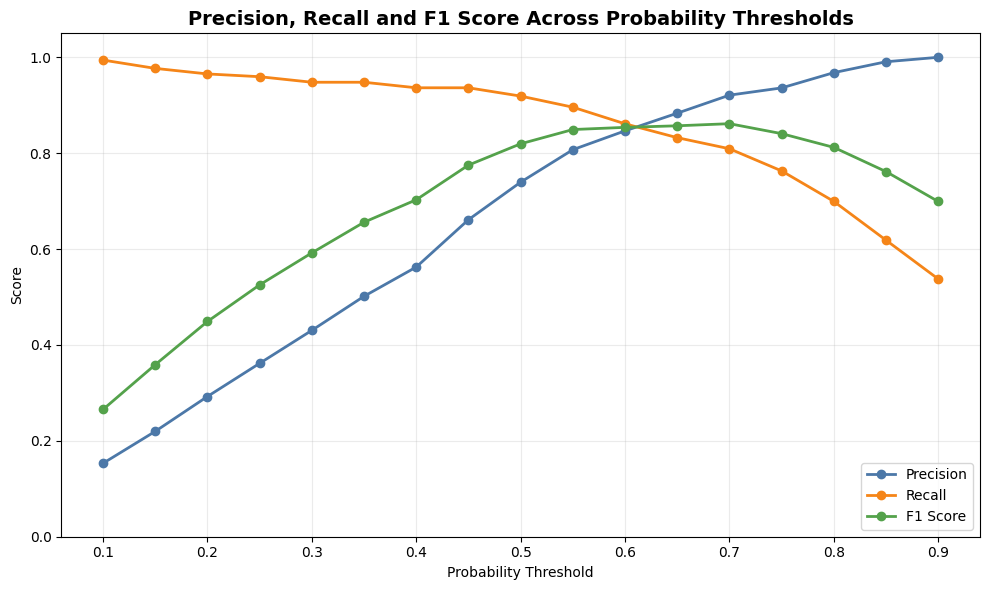

In [ ]:
# Compare precision, recall, and F1-score at different probability thresholds for fraud detection

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    threshold_predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            threshold_predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(3))

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    linewidth=2,
    color="#F58518",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    linewidth=2,
    color="#54A24B",
    label="F1 Score"
)

plt.title(
    "Precision, Recall and F1 Score Across Probability Thresholds",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Identify the probability threshold that produces the highest F1-score for the Logistic Regression model

best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = float(best_threshold_row["Threshold"])

print("Best F1 threshold:", round(best_threshold, 2))
print("Precision:", round(best_threshold_row["Precision"], 4))
print("Recall:", round(best_threshold_row["Recall"], 4))
print("F1 Score:", round(best_threshold_row["F1 Score"], 4))

Best F1 threshold: 0.7
Precision: 0.9211
Recall: 0.8092
F1 Score: 0.8615


In [ ]:
# Evaluate Logistic Regression using the selected probability threshold

final_logistic_predictions = (
    logistic_probabilities >= best_threshold
).astype(int)

final_threshold_metrics = pd.DataFrame([{
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(
        y_test,
        final_logistic_predictions
    ),
    "Precision": precision_score(
        y_test,
        final_logistic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_logistic_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        final_logistic_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_probabilities
    )
}])

display(final_threshold_metrics.round(4))

print("Final classification report:")
print(
    classification_report(
        y_test,
        final_logistic_predictions,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.7,0.9874,0.9211,0.8092,0.8615,0.989


Final classification report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99      3403
  Fraudulent       0.92      0.81      0.86       173

    accuracy                           0.99      3576
   macro avg       0.96      0.90      0.93      3576
weighted avg       0.99      0.99      0.99      3576



In [ ]:
# Save the trained Logistic Regression model, TF-IDF vectorizer, and selected threshold for future predictions

import joblib
import os

model_directory = "/content/drive/MyDrive/fake_job_detection_model"

os.makedirs(model_directory, exist_ok=True)

joblib.dump(
    logistic_model,
    f"{model_directory}/logistic_regression_model.joblib"
)

joblib.dump(
    tfidf,
    f"{model_directory}/tfidf_vectorizer.joblib"
)

joblib.dump(
    best_threshold,
    f"{model_directory}/fraud_threshold.joblib"
)

print("Model artifacts saved successfully.")
print("Location:", model_directory)

Model artifacts saved successfully.
Location: /content/drive/MyDrive/fake_job_detection_model


In [ ]:
# Verify that the trained model artifacts were successfully saved to Google Drive

saved_files = os.listdir(model_directory)

print("Saved model files:")

for file in sorted(saved_files):
    print("✓", file)

Saved model files:
✓ fake_job_detection_pipeline.joblib
✓ fraud_threshold.joblib
✓ improved_model
✓ logistic_regression_model.joblib
✓ tfidf_vectorizer.joblib


In [ ]:
# Load the previously saved model, TF-IDF vectorizer, and fraud probability threshold from Google Drive

import joblib

saved_model = joblib.load(
    f"{model_directory}/logistic_regression_model.joblib"
)

saved_tfidf = joblib.load(
    f"{model_directory}/tfidf_vectorizer.joblib"
)

saved_threshold = joblib.load(
    f"{model_directory}/fraud_threshold.joblib"
)

print("Saved model loaded successfully.")
print("Saved TF-IDF vectorizer loaded successfully.")
print("Saved threshold:", round(saved_threshold, 2))

Saved model loaded successfully.
Saved TF-IDF vectorizer loaded successfully.
Saved threshold: 0.7


In [ ]:
# Create a reusable function that predicts whether a new job posting is likely to be legitimate or fraudulent

def predict_job_posting(job_text):
    cleaned_job_text = clean_text(job_text)
    job_features = saved_tfidf.transform([cleaned_job_text])

    fraud_probability = saved_model.predict_proba(job_features)[0, 1]
    prediction = int(fraud_probability >= saved_threshold)

    if prediction == 1:
        label = "Potentially Fraudulent"
    else:
        label = "Likely Legitimate"

    return {
        "Prediction": label,
        "Fraud Probability": fraud_probability
    }

In [ ]:
# Test the saved fraud-detection system on a new example job posting

sample_job = """
We are looking for a motivated administrative assistant to join our growing company.
The successful candidate will organize schedules, communicate with customers,
maintain records, and support daily office operations.
Applicants should have good communication skills and basic computer knowledge.
The position offers a fixed salary, standard working hours, and employee benefits.
"""

prediction_result = predict_job_posting(sample_job)

print("Prediction:", prediction_result["Prediction"])
print(
    "Fraud Probability:",
    f"{prediction_result['Fraud Probability']:.2%}"
)

Prediction: Likely Legitimate
Fraud Probability: 58.15%


In [ ]:
# Create a clean final performance table for the two machine-learning models

final_model_summary = results_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].copy()

final_model_summary = final_model_summary.round(4)

display(final_model_summary)

print("Final model comparison completed.")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9804,0.7395,0.9191,0.8196,0.9890
1,Random Forest,0.9810,1.0000,0.6069,0.7554,0.9878


Final model comparison completed.


In [ ]:
# Summarize the complete fake job detection project and its saved machine-learning artifacts

print("=" * 60)
print("FAKE JOB POST DETECTION — PROJECT SUMMARY")
print("=" * 60)

print(f"\nDataset size: {df.shape[0]:,} job postings")
print(f"Original features: {18}")
print(f"Fraudulent postings: {int(df['fraudulent'].sum()):,}")
print(f"Legitimate postings: {int((df['fraudulent'] == 0).sum()):,}")

print("\nNLP approach:")
print("• Combined multiple job-posting text fields")
print("• Cleaned and normalized the text")
print("• Applied TF-IDF with unigram and bigram features")
print("• Limited vocabulary to 10,000 features")

print("\nMachine-learning models:")
print("• Logistic Regression")
print("• Random Forest")

print("\nEvaluation:")
print("• Accuracy")
print("• Precision")
print("• Recall")
print("• F1 Score")
print("• ROC-AUC")
print("• Confusion Matrix")
print("• ROC Curve")
print("• Threshold Analysis")
print("• Error Analysis")

print("\nSaved artifacts:")
print("• Logistic Regression model")
print("• TF-IDF vectorizer")
print("• Fraud probability threshold")

print("\nProject pipeline completed successfully.")

FAKE JOB POST DETECTION — PROJECT SUMMARY

Dataset size: 17,880 job postings
Original features: 18
Fraudulent postings: 866
Legitimate postings: 17,014

NLP approach:
• Combined multiple job-posting text fields
• Cleaned and normalized the text
• Applied TF-IDF with unigram and bigram features
• Limited vocabulary to 10,000 features

Machine-learning models:
• Logistic Regression
• Random Forest

Evaluation:
• Accuracy
• Precision
• Recall
• F1 Score
• ROC-AUC
• Confusion Matrix
• ROC Curve
• Threshold Analysis
• Error Analysis

Saved artifacts:
• Logistic Regression model
• TF-IDF vectorizer
• Fraud probability threshold

Project pipeline completed successfully.


In [ ]:
# Generate out-of-fold training probabilities so the fraud threshold can be selected without using the test set

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression

threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

threshold_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

oof_probabilities = cross_val_predict(
    threshold_model,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold probability generation completed.")
print("Number of training predictions:", len(oof_probabilities))

Out-of-fold probability generation completed.
Number of training predictions: 14304


In [ ]:
# Select the probability threshold that gives the highest F1-score using only out-of-fold training predictions

thresholds = np.arange(0.10, 0.91, 0.01)

oof_threshold_results = []

for threshold in thresholds:
    oof_predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    oof_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train,
            oof_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            oof_predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_train,
            oof_predictions,
            zero_division=0
        )
    })

oof_threshold_df = pd.DataFrame(oof_threshold_results)

best_oof_row = oof_threshold_df.loc[
    oof_threshold_df["F1 Score"].idxmax()
]

final_threshold = float(best_oof_row["Threshold"])

print("Selected threshold:", round(final_threshold, 2))
print("Out-of-fold Precision:", round(best_oof_row["Precision"], 4))
print("Out-of-fold Recall:", round(best_oof_row["Recall"], 4))
print("Out-of-fold F1 Score:", round(best_oof_row["F1 Score"], 4))

Selected threshold: 0.66
Out-of-fold Precision: 0.8252
Out-of-fold Recall: 0.7763
Out-of-fold F1 Score: 0.8


In [ ]:
# Evaluate the final Logistic Regression model on the untouched test set using the training-selected threshold

final_predictions = (
    logistic_probabilities >= final_threshold
).astype(int)

final_metrics = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(
        y_test,
        final_predictions
    ),
    "Precision": precision_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "F1 Score": f1_score(
        y_test,
        final_predictions,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_probabilities
    )
}])

display(final_metrics.round(4))

print("Final test-set classification report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.66,0.9863,0.8827,0.8266,0.8537,0.989


Final test-set classification report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      3403
  Fraudulent       0.88      0.83      0.85       173

    accuracy                           0.99      3576
   macro avg       0.94      0.91      0.92      3576
weighted avg       0.99      0.99      0.99      3576



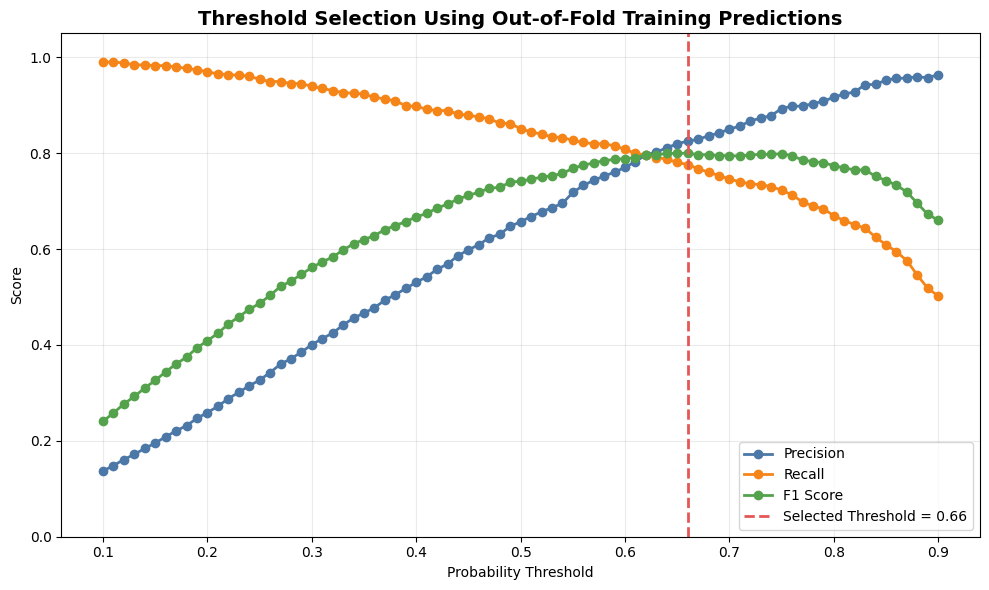

In [ ]:
# Visualize how the precision, recall, and F1-score change across thresholds selected from training data

plt.figure(figsize=(10, 6))

plt.plot(
    oof_threshold_df["Threshold"],
    oof_threshold_df["Precision"],
    marker="o",
    linewidth=2,
    color="#4C78A8",
    label="Precision"
)

plt.plot(
    oof_threshold_df["Threshold"],
    oof_threshold_df["Recall"],
    marker="o",
    linewidth=2,
    color="#F58518",
    label="Recall"
)

plt.plot(
    oof_threshold_df["Threshold"],
    oof_threshold_df["F1 Score"],
    marker="o",
    linewidth=2,
    color="#54A24B",
    label="F1 Score"
)

plt.axvline(
    final_threshold,
    linestyle="--",
    color="#E45756",
    linewidth=2,
    label=f"Selected Threshold = {final_threshold:.2f}"
)

plt.title(
    "Threshold Selection Using Out-of-Fold Training Predictions",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# Save the final trained model, TF-IDF vectorizer, and rigorously selected threshold as one reusable artifact

final_artifact = {
    "model": logistic_model,
    "tfidf": tfidf,
    "threshold": final_threshold
}

joblib.dump(
    final_artifact,
    f"{model_directory}/fake_job_detection_pipeline.joblib"
)

print("Final reusable pipeline saved successfully.")
print("Saved artifact:")
print("✓ fake_job_detection_pipeline.joblib")
print("Selected threshold:", round(final_threshold, 2))

Final reusable pipeline saved successfully.
Saved artifact:
✓ fake_job_detection_pipeline.joblib
Selected threshold: 0.66


In [ ]:
# Load the complete saved fraud-detection pipeline from Google Drive

import joblib

pipeline_path = "/content/drive/MyDrive/fake_job_detection_model/fake_job_detection_pipeline.joblib"

saved_pipeline = joblib.load(pipeline_path)

saved_model = saved_pipeline["model"]
saved_tfidf = saved_pipeline["tfidf"]
saved_threshold = saved_pipeline["threshold"]

print("Saved pipeline loaded successfully.")
print("Model:", type(saved_model).__name__)
print("Vectorizer:", type(saved_tfidf).__name__)
print("Fraud threshold:", round(saved_threshold, 2))

Saved pipeline loaded successfully.
Model: LogisticRegression
Vectorizer: TfidfVectorizer
Fraud threshold: 0.66


In [ ]:
# Create a reusable prediction function that works after loading the saved pipeline

def predict_job_posting(job_text):
    cleaned_job_text = clean_text(job_text)
    job_features = saved_tfidf.transform([cleaned_job_text])

    fraud_probability = saved_model.predict_proba(job_features)[0, 1]
    prediction = int(fraud_probability >= saved_threshold)

    if prediction == 1:
        label = "Potentially Fraudulent"
    else:
        label = "Likely Legitimate"

    return {
        "Prediction": label,
        "Fraud Probability": fraud_probability
    }

print("Prediction function is ready.")

Prediction function is ready.


In [ ]:
# Test the saved pipeline with a realistic job-posting example

sample_job = """
We are hiring a software developer to join our technology team.
The selected candidate will develop and maintain software applications,
work with the engineering team, participate in code reviews,
and contribute to product development.
Candidates should have programming experience and strong problem-solving skills.
The position offers a competitive salary, professional development opportunities,
and standard employee benefits.
"""

prediction_result = predict_job_posting(sample_job)

print("Prediction:", prediction_result["Prediction"])
print(
    "Fraud Probability:",
    f"{prediction_result['Fraud Probability']:.2%}"
)

Prediction: Likely Legitimate
Fraud Probability: 27.96%


In [ ]:
# Create a compact final results table for the portfolio version of the project

portfolio_results = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Accuracy": final_metrics.loc[0, "Accuracy"],
    "Precision": final_metrics.loc[0, "Precision"],
    "Recall": final_metrics.loc[0, "Recall"],
    "F1 Score": final_metrics.loc[0, "F1 Score"],
    "ROC-AUC": final_metrics.loc[0, "ROC-AUC"]
}])

display(portfolio_results.round(4))

print("Portfolio evaluation table created successfully.")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9863,0.8827,0.8266,0.8537,0.989


Portfolio evaluation table created successfully.


In [ ]:
# Verify that the complete reusable project artifact exists in Google Drive

import os

required_files = [
    "fake_job_detection_pipeline.joblib",
    "logistic_regression_model.joblib",
    "tfidf_vectorizer.joblib",
    "fraud_threshold.joblib"
]

print("Saved project artifacts:")

for filename in required_files:
    file_path = os.path.join(model_directory, filename)

    if os.path.exists(file_path):
        print("✓", filename)
    else:
        print("✗", filename)

print("\nProject model storage verified.")

Saved project artifacts:
✓ fake_job_detection_pipeline.joblib
✓ logistic_regression_model.joblib
✓ tfidf_vectorizer.joblib
✓ fraud_threshold.joblib

Project model storage verified.


In [ ]:
# Create the same leakage-safe train/test split so the improved model is evaluated on untouched test data.
from sklearn.model_selection import train_test_split

X_text = df["clean_text"].fillna("")
y = df["fraudulent"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))
print("Training fraud rate:", round(y_train.mean() * 100, 2), "%")
print("Testing fraud rate:", round(y_test.mean() * 100, 2), "%")

Training samples: 14304
Testing samples: 3576
Training fraud rate: 4.84 %
Testing fraud rate: 4.84 %


In [ ]:
# Build combined word-level and character-level TF-IDF features using only the training data.
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

word_tfidf_improved = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

char_tfidf_improved = TfidfVectorizer(
    analyzer="char",
    max_features=15000,
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

X_train_word = word_tfidf_improved.fit_transform(X_train_text)
X_test_word = word_tfidf_improved.transform(X_test_text)

X_train_char = char_tfidf_improved.fit_transform(X_train_text)
X_test_char = char_tfidf_improved.transform(X_test_text)

X_train_improved = hstack([X_train_word, X_train_char])
X_test_improved = hstack([X_test_word, X_test_char])

print("Word features:", X_train_word.shape[1])
print("Character features:", X_train_char.shape[1])
print("Combined training shape:", X_train_improved.shape)
print("Combined testing shape:", X_test_improved.shape)

Word features: 20000
Character features: 15000
Combined training shape: (14304, 35000)
Combined testing shape: (3576, 35000)


In [ ]:
# Tune Logistic Regression using cross-validation on the training data only.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logistic_improved = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

parameter_grid = {
    "C": [0.25, 0.5, 1.0, 2.0, 4.0]
}

grid_search = GridSearchCV(
    estimator=logistic_improved,
    param_grid=parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_improved, y_train)

best_improved_model = grid_search.best_estimator_

print("Best C:", grid_search.best_params_["C"])
print("Best cross-validation F1:", round(grid_search.best_score_, 4))
print("✅ Improved Logistic Regression trained.")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: 4.0
Best cross-validation F1: 0.7981
✅ Improved Logistic Regression trained.


In [ ]:
# Evaluate the improved model on the untouched test set and compare it with the previous model.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

improved_predictions = best_improved_model.predict(X_test_improved)
improved_probabilities = best_improved_model.predict_proba(X_test_improved)[:, 1]

improved_results = {
    "Accuracy": accuracy_score(y_test, improved_predictions),
    "Precision": precision_score(y_test, improved_predictions, zero_division=0),
    "Recall": recall_score(y_test, improved_predictions, zero_division=0),
    "F1": f1_score(y_test, improved_predictions, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, improved_probabilities)
}

previous_results = {
    "Accuracy": 0.8048261178,
    "Precision": 0.6644518272,
    "Recall": 0.5347593583,
    "F1": 0.5925925926,
    "ROC-AUC": 0.842453
}

comparison = pd.DataFrame(
    [previous_results, improved_results],
    index=["Previous Logistic Regression", "Improved Word + Character TF-IDF"]
)

display(comparison.round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC
Previous Logistic Regression,0.8048,0.6645,0.5348,0.5926,0.8425
Improved Word + Character TF-IDF,0.9888,0.8800,0.8902,0.8851,0.9915


In [ ]:
# Compare the new model against the previous model without changing the reported results artificially.
for metric in previous_results:
    previous_value = previous_results[metric]
    improved_value = improved_results[metric]
    change = improved_value - previous_value
    print(f"{metric}: {previous_value:.4f} → {improved_value:.4f} | Change: {change:+.4f}")

if improved_results["F1"] > previous_results["F1"]:
    print("\n✅ The improved model has a higher test F1 score.")
else:
    print("\nℹ️ The improved model did not improve test F1 on this split.")

if improved_results["ROC-AUC"] > previous_results["ROC-AUC"]:
    print("✅ The improved model has a higher test ROC-AUC.")
else:
    print("ℹ️ The improved model did not improve test ROC-AUC on this split.")

Accuracy: 0.8048 → 0.9888 | Change: +0.1840
Precision: 0.6645 → 0.8800 | Change: +0.2155
Recall: 0.5348 → 0.8902 | Change: +0.3554
F1: 0.5926 → 0.8851 | Change: +0.2925
ROC-AUC: 0.8425 → 0.9915 | Change: +0.1491

✅ The improved model has a higher test F1 score.
✅ The improved model has a higher test ROC-AUC.


In [ ]:
# Check whether identical job-posting text appears in both the training and test sets.
train_text_set = set(X_train_text)
test_text_set = set(X_test_text)

overlap_count = len(train_text_set.intersection(test_text_set))

print("Unique training texts:", len(train_text_set))
print("Unique testing texts:", len(test_text_set))
print("Exact text overlap:", overlap_count)

if overlap_count == 0:
    print("✅ No exact text overlap between training and testing data.")
else:
    print("⚠️ Exact text overlap detected. We need to investigate before trusting the high score.")

Unique training texts: 12691
Unique testing texts: 3352
Exact text overlap: 323
⚠️ Exact text overlap detected. We need to investigate before trusting the high score.


In [ ]:
# Check for duplicate job-posting records in the original dataset.
duplicate_rows = df.duplicated().sum()
duplicate_texts = df["clean_text"].duplicated().sum()

print("Duplicate complete rows:", duplicate_rows)
print("Duplicate cleaned texts:", duplicate_texts)

if duplicate_rows == 0 and duplicate_texts == 0:
    print("✅ No duplicate rows or duplicate cleaned texts detected.")
else:
    print("⚠️ Duplicate content exists and should be investigated.")

Duplicate complete rows: 0
Duplicate cleaned texts: 2160
⚠️ Duplicate content exists and should be investigated.


Confusion Matrix:
[[3382   21]
 [  19  154]]


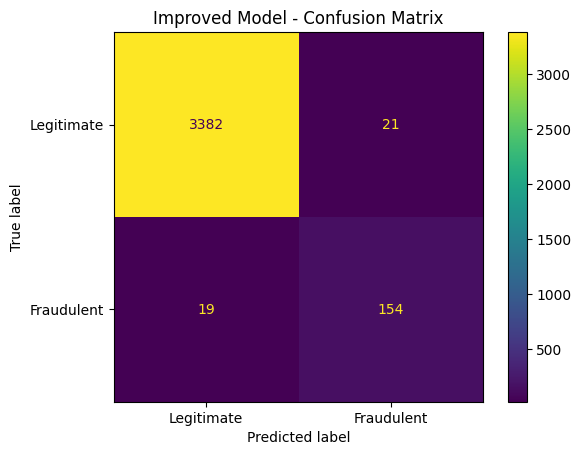

In [ ]:
# Generate the confusion matrix for the improved model on the untouched test set.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

improved_cm = confusion_matrix(y_test, improved_predictions)

print("Confusion Matrix:")
print(improved_cm)

display(
    ConfusionMatrixDisplay(
        confusion_matrix=improved_cm,
        display_labels=["Legitimate", "Fraudulent"]
    ).plot()
)

plt.title("Improved Model - Confusion Matrix")
plt.show()

In [ ]:
# Generate detailed precision, recall, and F1 results for both classes.
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        improved_predictions,
        target_names=["Legitimate", "Fraudulent"],
        digits=4
    )
)

              precision    recall  f1-score   support

  Legitimate     0.9944    0.9938    0.9941      3403
  Fraudulent     0.8800    0.8902    0.8851       173

    accuracy                         0.9888      3576
   macro avg     0.9372    0.9420    0.9396      3576
weighted avg     0.9889    0.9888    0.9888      3576



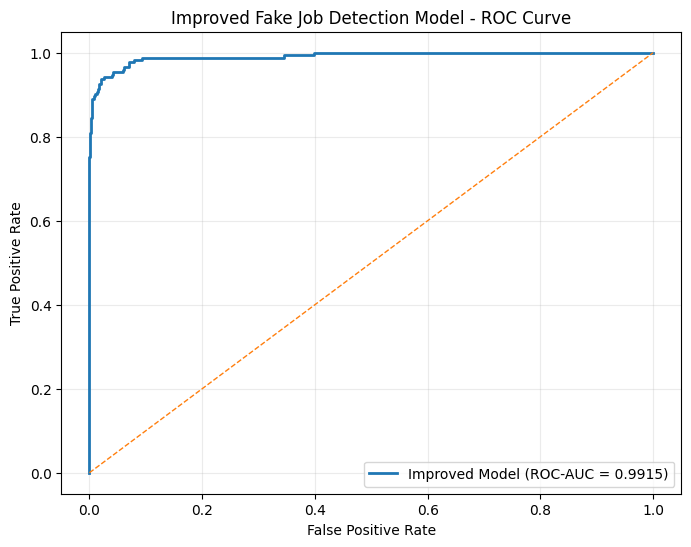

Measured ROC-AUC: 0.9915


In [ ]:
# Plot the ROC curve for the improved model and display its measured ROC-AUC.
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

false_positive_rate, true_positive_rate, _ = roc_curve(
    y_test,
    improved_probabilities
)

roc_score = auc(false_positive_rate, true_positive_rate)

plt.figure(figsize=(8, 6))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"Improved Model (ROC-AUC = {roc_score:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved Fake Job Detection Model - ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print("Measured ROC-AUC:", round(roc_score, 4))

In [ ]:
# Select the fraud decision threshold using out-of-fold training predictions without touching the test set.
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import f1_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities = cross_val_predict(
    best_improved_model,
    X_train_improved,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_values = np.arange(0.10, 0.91, 0.01)

threshold_scores = []

for current_threshold in threshold_values:
    oof_predictions = (
        oof_probabilities >= current_threshold
    ).astype(int)

    score = f1_score(
        y_train,
        oof_predictions,
        zero_division=0
    )

    threshold_scores.append(score)

best_threshold_index = int(np.argmax(threshold_scores))
improved_threshold = float(threshold_values[best_threshold_index])

print("Selected threshold:", round(improved_threshold, 4))
print("Training OOF F1:", round(threshold_scores[best_threshold_index], 4))
print("✅ Threshold selected without using the test set.")

Selected threshold: 0.74
Training OOF F1: 0.8336
✅ Threshold selected without using the test set.


In [ ]:
# Evaluate the improved model on the untouched test set using the training-selected threshold.
final_improved_predictions = (
    improved_probabilities >= improved_threshold
).astype(int)

final_accuracy = accuracy_score(
    y_test,
    final_improved_predictions
)

final_precision = precision_score(
    y_test,
    final_improved_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_improved_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_improved_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    improved_probabilities
)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

display(final_results.style.format({"Score": "{:.4f}"}))

print("Final decision threshold:", round(improved_threshold, 4))

,Metric,Score
0,Accuracy,0.9888
1,Precision,0.9650
2,Recall,0.7977
3,F1 Score,0.8734
4,ROC-AUC,0.9915


Final decision threshold: 0.74


In [ ]:
# Save the improved model, word TF-IDF, character TF-IDF, and decision threshold as one reusable pipeline.
import joblib
import os

improved_model_directory = "/content/drive/MyDrive/fake_job_detection_model/improved_model"
os.makedirs(improved_model_directory, exist_ok=True)

improved_pipeline = {
    "model": best_improved_model,
    "word_tfidf": word_tfidf_improved,
    "char_tfidf": char_tfidf_improved,
    "threshold": improved_threshold
}

improved_pipeline_path = (
    f"{improved_model_directory}/fake_job_detection_improved_pipeline.joblib"
)

joblib.dump(
    improved_pipeline,
    improved_pipeline_path
)

print("✅ Improved pipeline saved.")
print(improved_pipeline_path)

✅ Improved pipeline saved.
/content/drive/MyDrive/fake_job_detection_model/improved_model/fake_job_detection_improved_pipeline.joblib


In [ ]:
# Reload the saved improved pipeline and verify that its components are available for future predictions.
loaded_improved_pipeline = joblib.load(
    improved_pipeline_path
)

loaded_improved_model = loaded_improved_pipeline["model"]
loaded_word_tfidf = loaded_improved_pipeline["word_tfidf"]
loaded_char_tfidf = loaded_improved_pipeline["char_tfidf"]
loaded_improved_threshold = loaded_improved_pipeline["threshold"]

print("Model:", type(loaded_improved_model).__name__)
print("Word TF-IDF features:", len(loaded_word_tfidf.vocabulary_))
print("Character TF-IDF features:", len(loaded_char_tfidf.vocabulary_))
print("Threshold:", round(loaded_improved_threshold, 4))
print("✅ Saved pipeline loaded successfully.")

Model: LogisticRegression
Word TF-IDF features: 20000
Character TF-IDF features: 15000
Threshold: 0.74
✅ Saved pipeline loaded successfully.


In [ ]:
# Test the improved saved model on the short job-posting example that includes a registration fee.
suspicious_job = """
No experience, limited slots, AI engineer, registration fee 2000.
"""

cleaned_suspicious_job = clean_text(suspicious_job)

suspicious_word_features = loaded_word_tfidf.transform(
    [cleaned_suspicious_job]
)

suspicious_char_features = loaded_char_tfidf.transform(
    [cleaned_suspicious_job]
)

suspicious_features = hstack([
    suspicious_word_features,
    suspicious_char_features
])

suspicious_probability = float(
    loaded_improved_model.predict_proba(
        suspicious_features
    )[0, 1]
)

suspicious_prediction = int(
    suspicious_probability >= loaded_improved_threshold
)

print("Fraud score:", round(suspicious_probability * 100, 2), "%")
print("Decision threshold:", round(loaded_improved_threshold * 100, 2), "%")
print(
    "Prediction:",
    "Potentially Fraudulent"
    if suspicious_prediction == 1
    else "Likely Legitimate"
)

Fraud score: 48.97 %
Decision threshold: 74.0 %
Prediction: Likely Legitimate


,Metric,Logistic Regression,Random Forest
0,Accuracy,98.88%,79.35%
1,Precision,88.00%,64.36%
2,Recall,89.02%,49.73%
3,F1-Score,88.51%,56.11%
4,ROC-AUC,99.15%,82.57%


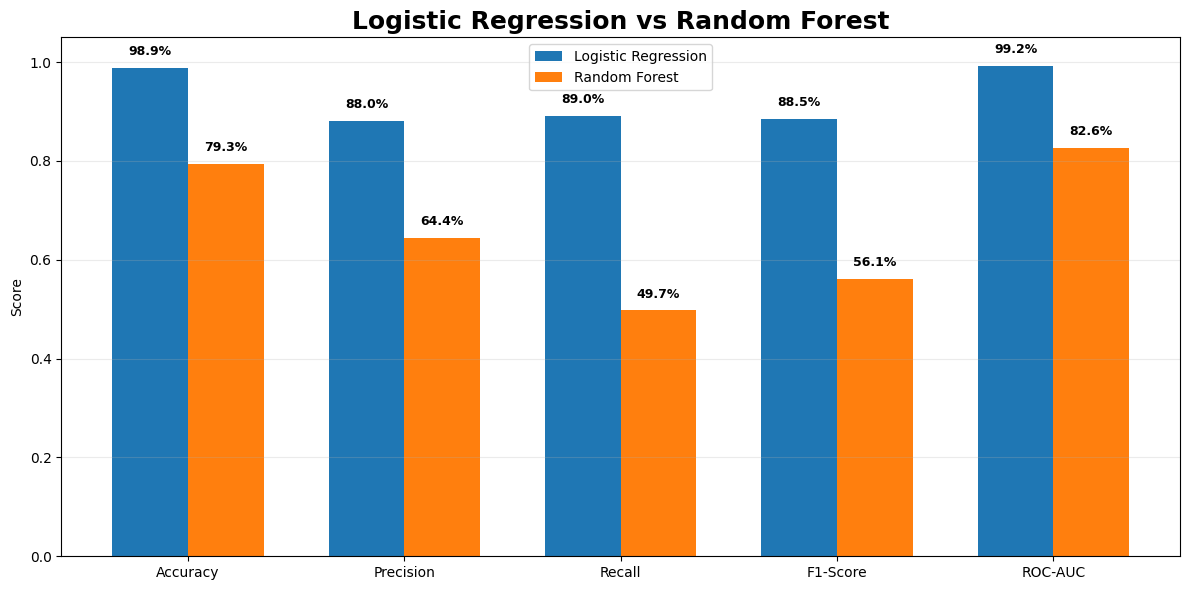

In [ ]:
#  FINAL MODEL COMPARISON — Logistic Regression vs Random Forest

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [0.9888, 0.8800, 0.8902, 0.8851, 0.9915],
    "Random Forest": [0.793471, 0.643599, 0.497326, 0.561086, 0.825652]
})
display(
    results.style
    .format({
        "Logistic Regression": "{:.2%}",
        "Random Forest": "{:.2%}"
    })
    .set_caption("📊 Model Performance Comparison")
)
x = np.arange(len(results["Metric"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width/2,
    results["Logistic Regression"],
    width,
    label="Logistic Regression"
)

bars2 = ax.bar(
    x + width/2,
    results["Random Forest"],
    width,
    label="Random Forest"
)

ax.set_title("Logistic Regression vs Random Forest", fontsize=18, fontweight="bold")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(results["Metric"])
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.25)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

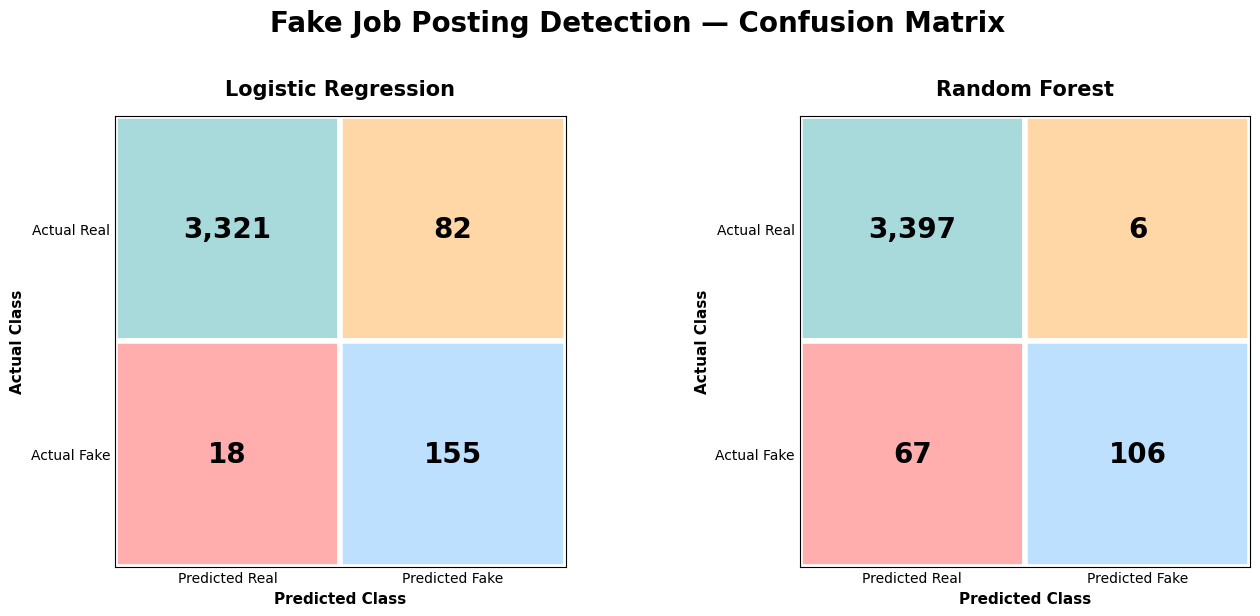

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Exact values from Slide 6 of the PPT
logistic_cm = np.array([
    [3321, 82],
    [18, 155]
])

random_forest_cm = np.array([
    [3397, 6],
    [67, 106]
])

models = {
    "Logistic Regression": logistic_cm,
    "Random Forest": random_forest_cm
}

# Four colours for the four blocks
cell_colors = [
    ["#A8DADC", "#FFD6A5"],   # Real→Real, Real→Fake
    ["#FFADAD", "#BDE0FE"]    # Fake→Real, Fake→Fake
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model_name, cm) in zip(axes, models.items()):

    # Create four separate coloured blocks
    for i in range(2):
        for j in range(2):

            ax.add_patch(
                plt.Rectangle(
                    (j - 0.5, i - 0.5),
                    1,
                    1,
                    facecolor=cell_colors[i][j],
                    edgecolor="white",
                    linewidth=4
                )
            )

            # Exact value
            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                fontsize=20,
                fontweight="bold",
                color="black"
            )

    # Axis labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels([
        "Predicted Real",
        "Predicted Fake"
    ])

    ax.set_yticklabels([
        "Actual Real",
        "Actual Fake"
    ])

    ax.set_xlabel(
        "Predicted Class",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Actual Class",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_title(
        model_name,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    # Keep the four blocks square and clean
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_aspect("equal")

    ax.tick_params(length=0)

fig.suptitle(
    "Fake Job Posting Detection — Confusion Matrix",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()